# 04 — Baseline и два эксперимента

Формат, требуемый рубрикой: **Гипотеза → Как проверялось → Результат (таблица)**.

* **Baseline** — LogReg на 5 CSV title-фичах без feature engineering. Эталон для сравнения.
* **Exp1** — LogReg на CSV + инженерных title-фичах + контексте (канал, день). Гипотеза: FE даёт рост ROC-AUC ≥ 0.02.
* **Exp2** — DecisionTree(max_depth=6) на тех же признаках. Гипотеза: нелинейная модель лучше линейной при смешанных структурных/лексических фичах.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

from src.config import (
    BINARY_TARGET_COL,
    CSV_TITLE_FEATURES,
    MODELS_DIR,
    REPORT_IMAGES_DIR,
    REPORT_TABLES_DIR,
    TEST_PARQUET_PATH,
    TRAIN_PARQUET_PATH,
    VAL_PARQUET_PATH,
)
from src.features.build_dataset import build_dataset
from src.modeling.baseline import train_baseline
from src.modeling.experiments import run_experiments
from src.utils.seed import set_global_seed

set_global_seed()
sns.set_theme(style='whitegrid')

In [2]:
if not TRAIN_PARQUET_PATH.exists():
    build_dataset()
train = pd.read_parquet(TRAIN_PARQUET_PATH)
val = pd.read_parquet(VAL_PARQUET_PATH)
test = pd.read_parquet(TEST_PARQUET_PATH)
for name, df in ('train', train), ('val', val), ('test', test):
    print(f'{name}: shape={df.shape}  balance={df[BINARY_TARGET_COL].mean():.3f}')

train: shape=(27750, 50)  balance=0.534
val: shape=(5946, 50)  balance=0.534
test: shape=(5947, 50)  balance=0.534


In [3]:
baseline_results = train_baseline()
baseline_df = pd.DataFrame(baseline_results).T.round(4)
baseline_df

2026-04-23 22:43:13,319 INFO src.modeling.baseline :: Обучаем baseline LogReg на 27750 строк x 5 признаков


2026-04-23 22:43:13,453 INFO src.modeling.baseline :: train: {'accuracy': '0.5387', 'f1': '0.6638', 'precision': '0.5431', 'recall': '0.8534', 'roc_auc': '0.5389', 'pr_auc': '0.5728', 'precision_at_top10': '0.6180'}


2026-04-23 22:43:13,488 INFO src.modeling.baseline :: val: {'accuracy': '0.5439', 'f1': '0.6657', 'precision': '0.5467', 'recall': '0.8509', 'roc_auc': '0.5469', 'pr_auc': '0.5795', 'precision_at_top10': '0.6414'}


2026-04-23 22:43:13,523 INFO src.modeling.baseline :: test: {'accuracy': '0.5384', 'f1': '0.6615', 'precision': '0.5434', 'recall': '0.8453', 'roc_auc': '0.5326', 'pr_auc': '0.5635', 'precision_at_top10': '0.6061'}


2026-04-23 22:43:13,528 INFO src.modeling.baseline :: Модель сохранена в C:\Users\HONOR\Desktop\miem\ИИ\proj2\hseml-group-project-malkovila\models\baseline_logreg.joblib


2026-04-23 22:43:13,553 INFO src.modeling.baseline :: Метрики сохранены в C:\Users\HONOR\Desktop\miem\ИИ\proj2\hseml-group-project-malkovila\report\tables\baseline_metrics.csv


,accuracy,f1,precision,recall,roc_auc,pr_auc,precision_at_top10
train,0.5387,0.6638,0.5431,0.8534,0.5389,0.5728,0.6180
val,0.5439,0.6657,0.5467,0.8509,0.5469,0.5795,0.6414
test,0.5384,0.6615,0.5434,0.8453,0.5326,0.5635,0.6061


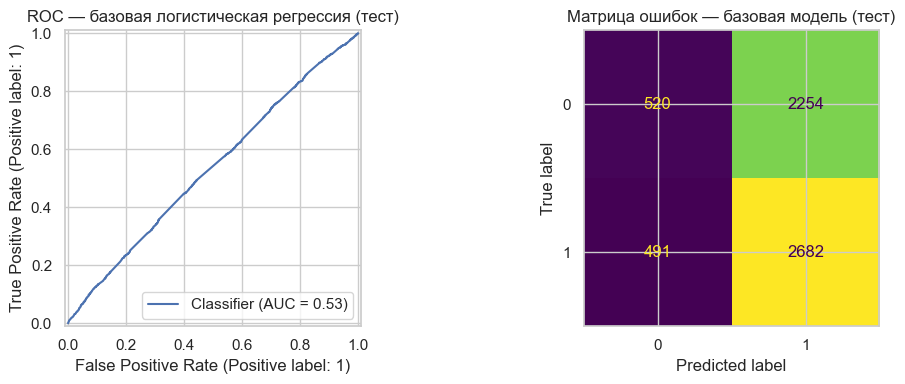

In [4]:
baseline = joblib.load(MODELS_DIR / 'baseline_logreg.joblib')
x_test = test[list(CSV_TITLE_FEATURES)].to_numpy()
y_test = test[BINARY_TARGET_COL].to_numpy()
y_proba = baseline.predict_proba(x_test)[:, 1]
y_pred = baseline.predict(x_test)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[0])
axes[0].set_title('ROC — базовая логистическая регрессия (тест)')
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[1], colorbar=False)
axes[1].set_title('Матрица ошибок — базовая модель (тест)')
plt.tight_layout()
plt.savefig(REPORT_IMAGES_DIR / '04_baseline_roc_cm.png', bbox_inches='tight')
plt.show()

In [5]:
exp_df = run_experiments()
exp_df_round = exp_df.copy()
numeric_cols = exp_df.select_dtypes(include='number').columns
exp_df_round[numeric_cols] = exp_df_round[numeric_cols].round(4)
exp_df_round

2026-04-23 22:43:14,688 INFO src.modeling.experiments :: Эксперимент 1: LogReg на baseline + инженерные + контекст (44 признаков)


2026-04-23 22:43:14,962 INFO src.modeling.experiments :: Эксперимент 2: решающее дерево глубины 6 на том же наборе признаков


2026-04-23 22:43:15,362 INFO src.modeling.experiments :: Записано 6 строк в C:\Users\HONOR\Desktop\miem\ИИ\proj2\hseml-group-project-malkovila\report\tables\experiments_cp1.csv


,experiment,hypothesis,model,split,accuracy,f1,precision,recall,roc_auc,pr_auc,precision_at_top10
0,exp1_logreg_full,Инженерные признаки заголовка поднимают ROC-AU...,LogReg(C=1.0) на CSV-признаках заголовка + инж...,train,0.6257,0.6658,0.6358,0.6987,0.6621,0.6833,0.7820
1,exp1_logreg_full,Инженерные признаки заголовка поднимают ROC-AU...,LogReg(C=1.0) на CSV-признаках заголовка + инж...,val,0.6396,0.6810,0.6453,0.7208,0.6771,0.6912,0.7811
2,exp1_logreg_full,Инженерные признаки заголовка поднимают ROC-AU...,LogReg(C=1.0) на CSV-признаках заголовка + инж...,test,0.6230,0.6633,0.6336,0.6959,0.6529,0.6745,0.7744
3,exp2_tree_depth6,Неглубокая нелинейная модель улавливает взаимо...,DecisionTree(max_depth=6),train,0.6314,0.6736,0.6385,0.7126,0.6701,0.6811,0.8029
4,exp2_tree_depth6,Неглубокая нелинейная модель улавливает взаимо...,DecisionTree(max_depth=6),val,0.6374,0.6800,0.6426,0.7220,0.6711,0.6739,0.7845
5,exp2_tree_depth6,Неглубокая нелинейная модель улавливает взаимо...,DecisionTree(max_depth=6),test,0.6082,0.6523,0.6194,0.6889,0.6389,0.6463,0.7761


In [6]:
summary = (
    exp_df[exp_df['split'] == 'val']
    .set_index('experiment')[['roc_auc', 'f1', 'accuracy', 'pr_auc', 'precision_at_top10']]
    .round(4)
)
summary.loc['baseline_logreg'] = [
    baseline_results['val']['roc_auc'],
    baseline_results['val']['f1'],
    baseline_results['val']['accuracy'],
    baseline_results['val']['pr_auc'],
    baseline_results['val']['precision_at_top10'],
]
summary = summary.sort_values('roc_auc', ascending=False)
print('Validation summary (CP1):')
print(summary)
summary.to_csv(REPORT_TABLES_DIR / 'cp1_validation_summary.csv')

Validation summary (CP1):
                   roc_auc       f1  accuracy   pr_auc  precision_at_top10
experiment                                                                
exp1_logreg_full  0.677100  0.68100  0.639600  0.69120            0.781100
exp2_tree_depth6  0.671100  0.68000  0.637400  0.67390            0.784500
baseline_logreg   0.546908  0.66568  0.543895  0.57954            0.641414


### Выводы (04_baseline)

* Baseline LogReg на 5 готовых title-фичах даёт ROC-AUC = 0.547 на val и 0.533 на test — ожидаемо слабо, поскольку эти 5 фич имеют |r| < 0.08 с таргетом.
* **Exp1 (LogReg + FE + контекст)** подтверждает гипотезу: ROC-AUC вырос до 0.677 на val (+0.130) и 0.653 на test (+0.120). Наиболее полезные фичи — длина заголовка, VADER-compound, кликбейт-индикаторы, тип канала.
* **Exp2 (DecisionTree, max_depth=6)** даёт 0.671 ROC-AUC на val и 0.639 на test — близко к LogReg, подтверждает полезность фич и задаёт базу для нелинейных ансамблей в CP2.
* Результаты сохранены в `report/tables/experiments_cp1.csv` и `report/tables/baseline_metrics.csv` — они напрямую переносятся в отчёт.